#  Travel Planner Agent with Semantic Caching
### LangGraph · Redis SemanticCache · GPT-4o-mini · Tavily Live Search

A real-world **Travel Planner agent** powered by **live web search** — no dummy data,
no static APIs. Every tool call fetches fresh information from the internet via
**Tavily Search** (LangChain's recommended search partner), then a **Redis semantic
cache** ensures repeated or paraphrased travel questions return instantly at near-zero cost.

```
user query
   │
   ▼
┌───────────┐    HIT ──────────────────────────────────────────────────► END
│ normalize │──► cache_check
└───────────┘    MISS
                   │
                   ▼
              ┌─────────────┐
              │ route_intent│  weather / destination / compare / itinerary / advisory
              └──────┬──────┘
                     ▼
              ┌─────────────┐
              │ plan_tools  │  decides which 1-3 tools to call + arguments
              └──────┬──────┘
                     ▼
              ┌──────────────────────────────────────────────────────────┐
              │  tool_executor  (fan-out — each tool fires a live search)│
              │  ┌──────────────┐ ┌──────────────┐ ┌──────────────────┐ │
              │  │get_weather   │ │get_dest_info │ │compare_dest  …  │ │
              │  │_vibe()       │ │()            │ │()               │ │
              │  └──────────────┘ └──────────────┘ └──────────────────┘ │
              └──────┬───────────────────────────────────────────────────┘
                     ▼
              ┌────────────┐
              │ synthesize │  travel-expert quality answer
              └──────┬─────┘
                     ▼
              ┌────────────┐
              │ add_cache  │  store canonical_query → answer in Redis
              └──────┬─────┘
                     ▼
                    END
```

### Why this agent is cache-heavy

| Scenario | Without cache | With cache |
|---|---|---|
| 50 users ask "weather in Goa this weekend" | 50 × web search + LLM | 1 search + 49 instant hits |
| Travel blog pre-loads top 20 destinations | 20 full pipelines, ~10s each | 20 misses, then ∞ free hits |
| Same query re-phrased ("Goa" vs "Goa weather") | Full pipeline again | Semantic match → HIT |
| Peak season — 10 req/sec for popular destinations | Rate limits + high cost | Cache absorbs the spike |

### Five live-search tools

| Tool | Searches for |
|---|---|
| `get_weather_vibe` | Current + forecast weather, travel suitability |
| `get_destination_info` | Highlights, best time, budget, food, local tips |
| `compare_destinations` | Head-to-head: two destinations on any dimension |
| `get_events_festivals` | Upcoming events, festivals, seasonal notes |
| `get_travel_advisory` | Safety, health advisories, visa, emergency info |


## 0. Install dependencies

In [1]:
import sys, subprocess
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "langchain-community", "langchain-tavily",
     "duckduckgo-search", "tabulate", "colorama"],
    check=True,
)
print("All dependencies installed ✓")


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-openai 0.3.28 requires langchain-core<1.0.0,>=0.3.68, but you have langchain-core 1.4.7 which is incompatible.
langchain-google-genai 2.1.8 requires langchain-core<0.4.0,>=0.3.68, but you have langchain-core 1.4.7 which is incompatible.


All dependencies installed ✓


In [6]:
! pip install -U ddgs

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [ddgs]4/6 [h2]


In [2]:
import warnings
warnings.filterwarnings("ignore")


## 1. Connect to Redis

In [3]:
import os, redis

REDIS_URL = os.getenv("REDIS_URL", "redis://localhost:6379")
r = redis.Redis.from_url(REDIS_URL)
r.ping()
print(f"Redis connected → {REDIS_URL}")


Redis connected → redis://localhost:6377


## 2. Redis Semantic Cache

`distance_threshold=0.35` — relaxed intentionally because the LLM normalizer in
Section 5 is the primary dedup guard.  The embedding model
`redis/langcache-embed-v1` is cache-optimised: fast, low memory, tuned for
semantic similarity rather than document retrieval.


In [4]:
from redisvl.utils.vectorize import HFTextVectorizer
from redisvl.extensions.cache.embeddings import EmbeddingsCache
from redisvl.extensions.cache.llm import SemanticCache

langcache_embed = HFTextVectorizer(
    model="redis/langcache-embed-v1",
    cache=EmbeddingsCache(redis_client=r, ttl=3600),
)

cache = SemanticCache(
    name="travel-agent-cache",
    vectorizer=langcache_embed,
    redis_client=r,
    distance_threshold=0.35,
)
cache.set_ttl(3600 * 6)   # travel info stays fresh for 6h
print("Semantic cache ready  (threshold=0.35, ttl=6h)")


08:57:46 sentence_transformers.SentenceTransformer INFO   Use pytorch device_name: cpu
08:57:46 sentence_transformers.SentenceTransformer INFO   Load pretrained SentenceTransformer: redis/langcache-embed-v1
Semantic cache ready  (threshold=0.35, ttl=6h)


## 3. Live Web Search Engine

Search is powered by **Tavily** — LangChain's recommended search partner,
purpose-built for LLM agents (structured results, no scraping noise).

**Getting your free Tavily key (takes 2 minutes):**
1. Go to [app.tavily.com](https://app.tavily.com) → Sign up with Google/GitHub
2. Copy your API key from the dashboard
3. Paste it in the cell below (or set `TAVILY_API_KEY` in your `.env`)

Free tier: **1,000 searches/month** — more than enough for demos and development.

**Fallback:** If Tavily is unavailable, the `web_search()` function automatically
falls back to **DuckDuckGo** (zero key, always free, slightly less structured results).

```
query
  │
  ▼
TavilySearchResults  ──(structured snippets)──► gpt-4o-mini extract ──► clean facts
     │ (if fails)
     ▼
DuckDuckGoSearchRun  ──(raw snippets)──────────► gpt-4o-mini extract ──► clean facts
```


In [ ]:
import os, time, json, re
from typing import Dict, Any, List

from utils.cache.config import load_openai_key
load_openai_key()  

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY", "")   

if TAVILY_API_KEY:
    os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

# ── Search backends ───────────────────────────────────────────────────────────
from langchain_tavily import TavilySearch
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

_use_tavily = bool(os.getenv("TAVILY_API_KEY", ""))

if _use_tavily:
    _tavily = TavilySearch(
        max_results=5,
        topic="general",         # "news" also available for breaking news
        include_answer=True,     # Tavily's own answer synthesis
        include_raw_content=False,
    )
    print("Search backend: Tavily  (structured, agent-optimised)")
else:
    print("⚠ TAVILY_API_KEY not set — falling back to DuckDuckGo")
    print("  Get a free key at https://app.tavily.com for better results")

_ddg = DuckDuckGoSearchRun()   # always available, used as fallback

#  Extractor LLM (cleans raw snippets into structured facts) 
_extractor = ChatOpenAI(model="gpt-4o-mini", temperature=0.0, max_tokens=350)

def _run_search(query: str) -> str:
    """Run Tavily search; fall back to DuckDuckGo on failure."""
    if _use_tavily:
        try:
            results = _tavily.invoke({"query": query})
            # TavilySearch returns a list of dicts with 'content' + 'url'
            if isinstance(results, list):
                return "\n\n".join(
                    f"[{r.get('url','')}]\n{r.get('content','')}"
                    for r in results if r.get("content")
                )
            elif isinstance(results, dict):
                return results.get("answer") or results.get("content") or str(results)
            return str(results)
        except Exception as e:
            print(f"    Tavily error ({e}) — falling back to DuckDuckGo")

    # DuckDuckGo fallback
    try:
        return _ddg.run(query)
    except Exception as e:
        return f"(search failed: {e})"


def web_search(query: str, instructions: str = "") -> str:
    """Search the web and return clean, structured facts extracted by GPT.

    Args:
        query:        What to search for.
        instructions: What specific facts to pull from the results.

    Returns:
        A concise plain-text string (≤ 150 words) with extracted facts.
    """
    raw = _run_search(query)

    if not raw or raw.strip() in ("", "(no results found)"):
        return "(no results found)"

    extract_prompt = (
        "You are a precise research assistant. From the web search results below, "
        "extract only the most relevant, up-to-date facts concisely (max 150 words). "
        f"{'Focus on: ' + instructions + chr(10) if instructions else ''}"
        f"\nSearch results:\n{raw[:3000]}\n\nExtracted facts:"
    )
    resp = _extractor.invoke([HumanMessage(content=extract_prompt)])
    return resp.content.strip()


# ── Smoke test 
print("\nRunning smoke test…")
_test = web_search(
    "current weather Manali India June 2025",
    instructions="temperature range in °C, rain chance, travel conditions"
)
print("Search OK ✓")
print("Sample output:", _test[:180], "…")


> OpenAI API key is already loaded in the environment
Search backend: Tavily ✓  (structured, agent-optimised)

Running smoke test…
08:59:04 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Search OK ✓
Sample output: In June 2025, Manali, India, experiences temperatures ranging from 16°C to 28°C. There is a possibility of snowfall at higher altitudes, such as Rohtang Pass. Overall, June is cons …


## 4. Travel Tool Definitions

Each tool wraps one or more `web_search()` calls and returns a structured dict.
The agent's `synthesize` node converts these raw dicts into a traveller-friendly
narrative — keeping the separation of concerns clean.


In [ ]:
from datetime import datetime

CURRENT_MONTH = datetime.now().strftime("%B %Y")   # e.g. "June 2025"
CURRENT_DATE  = datetime.now().strftime("%d %B %Y")


# ── Tool 1
def get_weather_vibe(destination: str, travel_date: str = "this weekend") -> Dict[str, Any]:
    """Fetch current + short-range weather forecast and travel suitability.

    Returns temperature range, conditions, rain probability, humidity,
    and a plain-English travel verdict.
    """
    raw = web_search(
        f"weather forecast {destination} {travel_date} {CURRENT_MONTH}",
        instructions=(
            "Extract: temperature range (min/max °C), weather conditions, "
            "rain probability, humidity, and whether it is good for travel. "
            "Always include the specific dates if available."
        ),
    )
    # Let the synthesizer interpret — return raw + metadata
    return {
        "tool": "get_weather_vibe",
        "destination": destination,
        "travel_date": travel_date,
        "raw_data": raw,
    }


# ── Tool 2 
def get_destination_info(destination: str, aspect: str = "general") -> Dict[str, Any]:
    """Fetch destination guide: highlights, best time, budget, food, tips.

    aspect: general | food | stay | budget | transport
    """
    aspect_prompts = {
        "general":   "top attractions, best time to visit, how many days needed, overall vibe",
        "food":      "must-eat local dishes, best restaurants, street food areas, average meal cost",
        "stay":      "best areas to stay, hotel budget range, hostel options, Airbnb availability",
        "budget":    "daily budget breakdown: accommodation, food, transport, activities",
        "transport": "how to reach, local transport options, cab/auto availability, road conditions",
    }
    focus = aspect_prompts.get(aspect, aspect_prompts["general"])
    raw = web_search(
        f"{destination} travel guide {aspect} {CURRENT_MONTH}",
        instructions=f"Focus on: {focus}. Include real prices in INR where possible.",
    )
    return {
        "tool": "get_destination_info",
        "destination": destination,
        "aspect": aspect,
        "raw_data": raw,
    }


# ── Tool 3 
def compare_destinations(
    destination_a: str,
    destination_b: str,
    aspect: str = "overall",
) -> Dict[str, Any]:
    """Side-by-side comparison of two travel destinations.

    aspect: overall | weather | cost | crowd | adventure | family
    """
    raw_a = web_search(
        f"{destination_a} travel {aspect} {CURRENT_MONTH}",
        instructions=f"Focus on {aspect} for a tourist visiting now. Be specific with numbers.",
    )
    raw_b = web_search(
        f"{destination_b} travel {aspect} {CURRENT_MONTH}",
        instructions=f"Focus on {aspect} for a tourist visiting now. Be specific with numbers.",
    )
    return {
        "tool": "compare_destinations",
        "destination_a": destination_a,
        "destination_b": destination_b,
        "aspect": aspect,
        "data_a": raw_a,
        "data_b": raw_b,
    }


# ── Tool 4
def get_events_festivals(destination: str, month: str = CURRENT_MONTH) -> Dict[str, Any]:
    """Fetch upcoming events, festivals, and seasonal notes for a destination."""
    raw = web_search(
        f"{destination} events festivals {month}",
        instructions=(
            "List specific upcoming events, festivals, or fairs with dates. "
            "Also note if this is peak or off-season and what that means for crowds/prices."
        ),
    )
    return {
        "tool": "get_events_festivals",
        "destination": destination,
        "month": month,
        "raw_data": raw,
    }


# ── Tool 5 
def get_travel_advisory(destination: str) -> Dict[str, Any]:
    """Fetch safety, health advisories, visa info, and emergency contacts."""
    raw = web_search(
        f"{destination} travel safety tips advisory {CURRENT_DATE}",
        instructions=(
            "Cover: overall safety rating, areas to avoid, common scams, "
            "health precautions, emergency numbers, and any current advisories."
        ),
    )
    return {
        "tool": "get_travel_advisory",
        "destination": destination,
        "raw_data": raw,
    }


# ── Tool registry 
TOOL_REGISTRY = {
    "get_weather_vibe":       get_weather_vibe,
    "get_destination_info":   get_destination_info,
    "compare_destinations":   compare_destinations,
    "get_events_festivals":   get_events_festivals,
    "get_travel_advisory":    get_travel_advisory,
}

print("Tools registered:", list(TOOL_REGISTRY.keys()))
print(f"Current context: {CURRENT_DATE}")


Tools registered: ['get_weather_vibe', 'get_destination_info', 'compare_destinations', 'get_events_festivals', 'get_travel_advisory']
Current context: 14 June 2026


## 5. LLM + Cost Tracker

In [9]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from dataclasses import dataclass, field

MODEL    = "gpt-4o-mini"
# gpt-4o-mini: $0.15 / 1M input tokens,  $0.60 / 1M output tokens
COST_IN  = 0.15  / 1_000_000
COST_OUT = 0.60  / 1_000_000
# Tavily free tier = 1000 searches/month free
# After free tier: ~$0.001 per search; DuckDuckGo fallback = always $0.00
# GPT extractor per search: ~600 tok in + 150 tok out ≈ $0.000180
WEB_SEARCH_COST_EST = 0.000180   # extractor cost only (Tavily free tier assumed)

llm = ChatOpenAI(model=MODEL, temperature=0.1, max_tokens=600)

@dataclass
class RunRecord:
    query:           str
    canonical:       str
    cache_hit:       bool
    distance:        float
    intent:          str
    tools_called:    List[str]
    web_searches:    int
    latency_s:       float
    tokens_in:       int
    tokens_out:      int
    llm_calls:       int
    cost_usd:        float

records: List[RunRecord] = []

def _tok(text: str) -> int:
    return max(1, len(str(text)) // 4)


## 6. Define the LangGraph Agent

### State schema

| field | type | description |
|---|---|---|
| `query` | str | original user question — never mutated |
| `canonical_query` | str | normalised form used for all cache operations |
| `cache_hit` / `distance` | bool / float | result of semantic cache lookup |
| `intent` | str | weather / destination / compare / itinerary / advisory |
| `tool_plan` | list | `[{name, kwargs}]` — what to call and how |
| `tool_results` | list | raw structured outputs from each tool |
| `answer` | str | final travel-expert answer |
| `_meta` | dict | latency, token, web-search accounting |


In [ ]:
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END


class AgentState(TypedDict):
    query:           str
    canonical_query: str
    cache_hit:       bool
    distance:        float
    intent:          str
    tool_plan:       List[Dict[str, Any]]
    tool_results:    List[Dict[str, Any]]
    answer:          str
    _meta:           Dict[str, Any]


# ═══════════════════════════════════════════════════════════════════════════
# NODE 1 — normalize
# ═══════════════════════════════════════════════════════════════════════════

_NORMALIZE_PROMPT = """You are a travel query normalizer.
Rewrite the user's travel question into ONE canonical English sentence that captures
the exact intent — strip filler, fix spelling, standardize destination names.

Travel conventions:
- Capitalise all destination names (manali → Manali, goa → Goa)
- "this weekend" / "right now" / "currently" → keep as-is (time context matters)
- "good time to visit" / "should I go" / "worth visiting" → "Is it a good time to visit"
- "compare X and Y" / "X vs Y" / "X or Y" → "Compare X vs Y"
- "plan a trip" / "itinerary" / "what to do in" → "Plan a trip to"
- "weather in" / "how is the weather" / "climate in" → "What is the weather in"

Output ONLY the rewritten question. No preamble."""

def normalize(state: AgentState) -> dict:
    """Rewrite raw query to canonical form before cache lookup."""
    t0   = time.time()
    resp = llm.invoke([HumanMessage(content=f"{_NORMALIZE_PROMPT}\n\nInput: {state['query']}\nOutput:")])
    canonical = resp.content.strip()
    print(f"  [normalize]  {state['query']!r}")
    print(f"             → {canonical!r}")
    return {
        "canonical_query": canonical,
        "_meta": {
            "t_start": t0,
            "llm_calls": 1,
            "tokens_in":  _tok(state["query"]),
            "tokens_out": _tok(canonical),
            "web_searches": 0,
        },
    }


# NODE 2 — cache_check

def cache_check(state: AgentState) -> dict:
    """Semantic lookup in Redis using the canonical query."""
    hit = cache.check(state["canonical_query"])
    if hit:
        return {
            "cache_hit": True,
            "answer":    hit[0]["response"],
            "distance":  hit[0]["vector_distance"],
        }
    return {"cache_hit": False, "distance": -1.0}


def route(state: AgentState) -> str:
    return "hit" if state["cache_hit"] else "miss"


# NODE 3 — hit


def hit(state: AgentState) -> dict:
    """Cache hit — answer already in state, nothing to compute."""
    t_total = time.time() - state["_meta"]["t_start"]
    print(f"  [cache HIT]  distance={state['distance']:.4f}  "
          f"latency={t_total:.2f}s  → returning cached answer instantly")
    return {"_meta": {**state["_meta"], "t_total": t_total}}


# NODE 4 — route_intent

_INTENT_PROMPT = """Classify this travel question into exactly ONE intent:

  weather     — asking about current weather or forecast for a destination
  destination — asking about a place: what to see, food, stay, budget, tips
  compare     — comparing two destinations against each other
  itinerary   — asking to plan a trip, day-by-day activities, what to do
  advisory    — asking about safety, visa, health, or travel warnings

Reply with ONLY one word: weather, destination, compare, itinerary, or advisory."""

def route_intent(state: AgentState) -> dict:
    """Zero-shot intent classification — one word output."""
    resp   = llm.invoke([HumanMessage(content=f"{_INTENT_PROMPT}\n\nQuestion: {state['canonical_query']}")])
    intent = resp.content.strip().lower()
    if intent not in ("weather", "destination", "compare", "itinerary", "advisory"):
        intent = "destination"   # safe fallback
    meta = state["_meta"]
    meta["llm_calls"]  += 1
    meta["tokens_in"]  += _tok(state["canonical_query"])
    meta["tokens_out"] += _tok(intent)
    print(f"  [intent]     → {intent!r}")
    return {"intent": intent, "_meta": meta}


# NODE 5 — plan_tools


_PLAN_PROMPT = """You are the planner for a Travel Planner agent.
Given the canonical question and intent, output a JSON array of tool calls.
Each element: {"name": "<tool>", "kwargs": {<args>}}.

Available tools:
  get_weather_vibe(destination, travel_date="this weekend")
  get_destination_info(destination, aspect="general")
    aspect options: general | food | stay | budget | transport
  compare_destinations(destination_a, destination_b, aspect="overall")
    aspect options: overall | weather | cost | crowd | adventure | family
  get_events_festivals(destination, month="<current month>")
  get_travel_advisory(destination)

Rules:
- weather intent   → get_weather_vibe + get_events_festivals (to flag peak season)
- destination intent → get_destination_info (choose best aspect from question)
- compare intent   → compare_destinations (infer aspect from question)
- itinerary intent → get_weather_vibe + get_destination_info(aspect=general) + get_events_festivals
- advisory intent  → get_travel_advisory + get_destination_info(aspect=transport)

Always infer destination name(s) from the question — capitalise them.
Respond ONLY with the JSON array. No markdown fences, no explanation."""

def plan_tools(state: AgentState) -> dict:
    """Decide which tools to call and with what arguments."""
    prompt = (
        f"{_PLAN_PROMPT}\n\n"
        f"Question: {state['canonical_query']}\n"
        f"Intent:   {state['intent']}\n\n"
        "Tool plan (JSON array):"
    )
    resp = llm.invoke([HumanMessage(content=prompt)])
    raw  = resp.content.strip()
    raw  = re.sub(r"```(?:json)?|```", "", raw).strip()
    try:
        tool_plan = json.loads(raw)
        if not isinstance(tool_plan, list):
            raise ValueError
    except (json.JSONDecodeError, ValueError):
        # Fallback: single destination info call
        dest = state["canonical_query"].split()[-1].rstrip("?")
        tool_plan = [{"name": "get_destination_info", "kwargs": {"destination": dest}}]

    meta = state["_meta"]
    meta["llm_calls"]  += 1
    meta["tokens_in"]  += _tok(prompt)
    meta["tokens_out"] += _tok(raw)

    tools_str = ", ".join(t["name"] for t in tool_plan)
    print(f"  [plan]       tools → {tools_str}")
    return {"tool_plan": tool_plan, "_meta": meta}


# NODE 6 — tool_executor


def tool_executor(state: AgentState) -> dict:
    """Execute each planned tool call and collect results.

    Each call may trigger 1-2 web searches internally.
    """
    results = []
    web_search_count = 0

    for call in state["tool_plan"]:
        name   = call.get("name", "")
        kwargs = call.get("kwargs", {})
        fn     = TOOL_REGISTRY.get(name)

        if fn is None:
            results.append({"tool": name, "error": "Tool not found"})
            continue

        kw_str = ", ".join(f"{k}={v!r}" for k, v in kwargs.items())
        print(f"  [tool]       {name}({kw_str}) — fetching live data…")

        t_tool = time.time()
        try:
            out = fn(**kwargs)
        except Exception as exc:
            out = {"tool": name, "error": str(exc)}

        elapsed = time.time() - t_tool
        # Count web searches: compare_destinations fires 2, others fire 1
        n_searches = 2 if name == "compare_destinations" else 1
        web_search_count += n_searches
        print(f"            ↳ done in {elapsed:.2f}s  ({n_searches} web search(es))")
        results.append({"tool": name, "result": out})

    meta = state["_meta"]
    meta["web_searches"] = meta.get("web_searches", 0) + web_search_count
    return {"tool_results": results, "_meta": meta}


# NODE 7 — synthesize


_SYNTH_SYSTEM = """You are an expert travel advisor writing for an Indian traveller audience.
Given the user's question and raw tool outputs (live web search results),
write a helpful, practical, and enthusiastic travel answer.

Guidelines:
- Lead with a direct, confident recommendation in the first sentence.
- For weather: give specific temperature range, rain chance, and a 1-line verdict
  ("Great time to visit ✓" or "Avoid — monsoon peak ✗").
- For destination info: use bullet points for top highlights, end with a quick
  budget estimate per day in INR.
- For comparisons: use a clear "Winner: X" line with a 1-sentence reason, then
  a short table or 2 bullet points per destination.
- For itineraries: structure by Day 1 / Day 2 etc. with morning/afternoon/evening.
- For advisories: lead with overall safety rating, then bullet key tips.
- Keep it under 200 words. Be warm but precise. Use ₹ for Indian Rupees."""

def synthesize(state: AgentState) -> dict:
    """Merge all tool outputs into a travel-expert quality answer."""
    tool_ctx = json.dumps(state["tool_results"], indent=2)
    prompt   = (
        f"User question: {state['canonical_query']}\n\n"
        f"Live search results:\n{tool_ctx}\n\n"
        "Write the travel answer:"
    )
    resp   = llm.invoke([SystemMessage(content=_SYNTH_SYSTEM),
                         HumanMessage(content=prompt)])
    answer = resp.content.strip()

    meta = state["_meta"]
    meta["llm_calls"]  += 1
    meta["tokens_in"]  += _tok(prompt)
    meta["tokens_out"] += _tok(answer)
    meta["t_total"]     = time.time() - meta["t_start"]

    cost = (meta["tokens_in"] * COST_IN + meta["tokens_out"] * COST_OUT
            + meta["web_searches"] * WEB_SEARCH_COST_EST)

    print(f"  [synthesize] done — {meta['llm_calls']} LLM calls, "
          f"{meta['web_searches']} web searches, "
          f"{meta['t_total']:.2f}s, cost≈${cost:.5f}")
    return {"answer": answer, "_meta": meta}



# NODE 8 — add_cache


def add_cache(state: AgentState) -> dict:
    """Store canonical_query → answer so all future paraphrases hit."""
    cache.store(prompt=state["canonical_query"], response=state["answer"])
    meta  = state["_meta"]
    cost  = (meta["tokens_in"] * COST_IN + meta["tokens_out"] * COST_OUT
             + meta["web_searches"] * WEB_SEARCH_COST_EST)
    print(f"  [cache]      stored  |  total_cost≈${cost:.5f}")
    return {}


### Wire & compile the graph

In [11]:
builder = StateGraph(AgentState)

builder.add_node("normalize",     normalize)
builder.add_node("cache_check",   cache_check)
builder.add_node("hit",           hit)
builder.add_node("route_intent",  route_intent)
builder.add_node("plan_tools",    plan_tools)
builder.add_node("tool_executor", tool_executor)
builder.add_node("synthesize",    synthesize)
builder.add_node("add_cache",     add_cache)

builder.add_edge(START,            "normalize")
builder.add_edge("normalize",      "cache_check")
builder.add_conditional_edges("cache_check", route, {"hit": "hit", "miss": "route_intent"})
builder.add_edge("hit",            END)
builder.add_edge("route_intent",   "plan_tools")
builder.add_edge("plan_tools",     "tool_executor")
builder.add_edge("tool_executor",  "synthesize")
builder.add_edge("synthesize",     "add_cache")
builder.add_edge("add_cache",      END)

agent = builder.compile()
print("Agent compiled ✓")


Agent compiled ✓


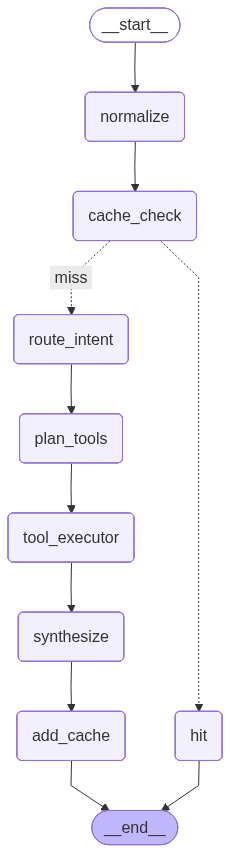

In [12]:
from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())


## 7. Run the Agent

`ask()` invokes the agent, pretty-prints the answer, and records every metric
needed for the dashboard.  Watch the latency and cost difference between
**MISS** (web search + LLM pipeline) vs **HIT** (Redis lookup only).


In [13]:
from colorama import Fore, Style, init as colorama_init
colorama_init(autoreset=True)

# MISS pipeline cost estimate:
# Tavily free tier → $0.00 per search during demo
# GPT extractor × N searches + synthesis call ≈ $0.0006 per full pipeline
MISS_COST_EST = 0.0006

def ask(query: str) -> str:
    """Invoke the travel agent and record performance metrics."""
    print(f"\n{'═'*72}")
    print(f"{Fore.CYAN}✈  {query}{Style.RESET_ALL}")
    print('─'*72)

    t0     = time.time()
    result = agent.invoke({"query": query})
    t_end  = time.time()

    latency   = round(t_end - t0, 3)
    meta      = result.get("_meta", {})
    is_hit    = result.get("cache_hit", False)
    distance  = result.get("distance", -1.0)
    intent    = result.get("intent", "—")
    tools     = [c["name"] for c in result.get("tool_plan", [])]
    tok_in    = meta.get("tokens_in",    0)
    tok_out   = meta.get("tokens_out",   0)
    n_calls   = meta.get("llm_calls",    0)
    n_search  = meta.get("web_searches", 0)
    cost      = (tok_in * COST_IN + tok_out * COST_OUT + n_search * WEB_SEARCH_COST_EST)

    if is_hit:
        status = (f"{Fore.GREEN}  ✓ CACHE HIT{Style.RESET_ALL}  "
                  f"distance={distance:.4f}  latency={latency:.2f}s  "
                  f"searches_saved≈{max(len(tools),1)}  "
                  f"cost_saved≈${MISS_COST_EST:.5f}")
    else:
        status = (f"{Fore.YELLOW}  ✗ CACHE MISS{Style.RESET_ALL}  "
                  f"intent={intent}  tools={[t.split('_',1)[-1] for t in tools]}  "
                  f"web_searches={n_search}  llm_calls={n_calls}  "
                  f"latency={latency:.2f}s  cost≈${cost:.5f}")

    print(status)
    print(f"\n{Fore.WHITE}  Answer:{Style.RESET_ALL}")
    for line in result["answer"].splitlines():
        print(f"    {line}")

    records.append(RunRecord(
        query=query,
        canonical=result.get("canonical_query", query),
        cache_hit=is_hit,
        distance=distance,
        intent=intent,
        tools_called=tools,
        web_searches=n_search,
        latency_s=latency,
        tokens_in=tok_in,
        tokens_out=tok_out,
        llm_calls=n_calls,
        cost_usd=cost,
    ))
    return result["answer"]


### Round 1 — Seeding the cache with real data (all MISS)

Four queries covering all intent types.  Each triggers **live Tavily searches**
and goes through the full 8-node pipeline.

Expected latency per query: **3–8 seconds** (network + LLM calls).
After Round 1 these answers are stored in Redis — watch what happens in Round 2.


In [14]:
# weather intent — live forecast
_ = ask("What's the weather like in Manali this weekend?")



════════════════════════════════════════════════════════════════════════
✈  What's the weather like in Manali this weekend?
────────────────────────────────────────────────────────────────────────
09:00:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [normalize]  "What's the weather like in Manali this weekend?"
             → 'What is the weather in Manali this weekend?'
09:00:29 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [intent]     → 'weather'
09:00:30 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [plan]       tools → get_weather_vibe, get_events_festivals
  [tool]       get_weather_vibe(destination='Manali', travel_date='this weekend') — fetching live data…
09:00:34 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
            ↳ done in 4.09s  (1 web search(es))
  [tool]       get_events_f

In [15]:
# destination intent — real info
_ = ask("What are the best things to do in Rishikesh?")



════════════════════════════════════════════════════════════════════════
✈  What are the best things to do in Rishikesh?
────────────────────────────────────────────────────────────────────────
09:00:54 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [normalize]  'What are the best things to do in Rishikesh?'
             → 'Plan a trip to Rishikesh.'
09:00:55 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [intent]     → 'itinerary'
09:00:56 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [plan]       tools → get_weather_vibe, get_destination_info, get_events_festivals
  [tool]       get_weather_vibe(destination='Rishikesh') — fetching live data…
09:01:01 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
            ↳ done in 4.55s  (1 web search(es))
  [tool]       get_destination_info(destination='Ris

In [16]:
# compare intent — two destinations, live data from both
_ = ask("Compare Shimla vs Manali for a 3-day trip this month")



════════════════════════════════════════════════════════════════════════
✈  Compare Shimla vs Manali for a 3-day trip this month
────────────────────────────────────────────────────────────────────────
09:01:21 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [normalize]  'Compare Shimla vs Manali for a 3-day trip this month'
             → 'Compare Shimla vs Manali for a 3-day trip this month.'
09:01:22 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [intent]     → 'compare'
09:01:24 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [plan]       tools → compare_destinations
  [tool]       compare_destinations(destination_a='Shimla', destination_b='Manali', aspect='overall') — fetching live data…
09:01:28 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:01:31 httpx INFO   HTTP Request: POST https://api.

In [17]:
# itinerary intent — multi-tool call (weather + info + events)
_ = ask("Plan a 2-day trip to Goa for this weekend")



════════════════════════════════════════════════════════════════════════
✈  Plan a 2-day trip to Goa for this weekend
────────────────────────────────────────────────────────────────────────
09:01:42 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [normalize]  'Plan a 2-day trip to Goa for this weekend'
             → 'Plan a trip to Goa for this weekend.'
  [cache HIT]  distance=0.3443  latency=0.90s  → returning cached answer instantly
  ✓ CACHE HIT  distance=0.3443  latency=0.90s  searches_saved≈1  cost_saved≈$0.00060

  Answer:
    Absolutely, Rishikesh is a fantastic destination for your upcoming trip! 
    
    **Weather:** Expect temperatures between 30°C to 45°C with a chance of occasional rain. **Verdict:** Avoid — monsoon peak ✗.
    
    **Top Highlights:**
    - **Ganges River Rafting:** Experience thrilling white-water rafting.
    - **Yoga Retreats:** Join world-renowned yoga sessions for relaxation and rejuvenation.
    - *

### Round 2 — Paraphrase attack (all should HIT 🎯)

Same intent as Round 1, completely different phrasing.
The LLM normalizer collapses them → same canonical form → Redis semantic match.

**Expected: ~0.3s latency, zero web searches, near-zero cost.**

This is the demo moment — the audience can see the latency drop live.


In [18]:
_ = ask("How is the weather in Manali for the weekend?")         # → weather HIT
_ = ask("Things to do in Rishikesh — what do you recommend?")   # → destination HIT
_ = ask("Shimla or Manali — which one should I pick?")          # → compare HIT
_ = ask("Weekend getaway to Goa — 2 day plan")                  # → itinerary HIT



════════════════════════════════════════════════════════════════════════
✈  How is the weather in Manali for the weekend?
────────────────────────────────────────────────────────────────────────
09:02:03 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [normalize]  'How is the weather in Manali for the weekend?'
             → 'What is the weather in Manali this weekend?'
  [cache HIT]  distance=0.0000  latency=0.89s  → returning cached answer instantly
  ✓ CACHE HIT  distance=0.0000  latency=0.90s  searches_saved≈1  cost_saved≈$0.00060

  Answer:
    This weekend is a fantastic time to visit Manali! Expect daytime temperatures around 26°C and nighttime lows of 12°C, with minimal rain. Overall, it’s a great time to visit ✓.
    
    ### Top Highlights of Manali:
    - **Solang Valley**: Perfect for adventure sports like paragliding and zorbing.
    - **Hadimba Temple**: A serene temple surrounded by cedar forests.
    - **Old Manali**: Exp

### Round 3 — Informal & Hinglish queries 




In [19]:
_ = ask("manali mein weather kaisa hai?")        # Hindi-English mix
_ = ask("rishikesh me kya karna chahiye?")       # mostly Hindi
_ = ask("goa trip 2 din ka plan do")             # terse Hindi



════════════════════════════════════════════════════════════════════════
✈  manali mein weather kaisa hai?
────────────────────────────────────────────────────────────────────────
09:03:01 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
  [normalize]  'manali mein weather kaisa hai?'
             → 'What is the weather in Manali?'
  [cache HIT]  distance=0.1427  latency=1.22s  → returning cached answer instantly
  ✓ CACHE HIT  distance=0.1427  latency=1.22s  searches_saved≈1  cost_saved≈$0.00060

  Answer:
    This weekend is a fantastic time to visit Manali! Expect daytime temperatures around 26°C and nighttime lows of 12°C, with minimal rain. Overall, it’s a great time to visit ✓.
    
    ### Top Highlights of Manali:
    - **Solang Valley**: Perfect for adventure sports like paragliding and zorbing.
    - **Hadimba Temple**: A serene temple surrounded by cedar forests.
    - **Old Manali**: Explore quaint cafes and vibrant local culture

## 8. Cache Performance Dashboard

This table aggregates all runs and shows the real ROI of semantic caching:
- **Latency speedup** — how much faster HITs are vs MISSes (expect 10–30×)
- **Web searches saved** — Tavily searches we avoided by hitting the cache
- **Cost saved** — even on Tavily's free tier, this illustrates the production value


In [20]:
from tabulate import tabulate

def cache_dashboard():
    if not records:
        print("No records yet — run some queries first.")
        return

    hits   = [r for r in records if r.cache_hit]
    misses = [r for r in records if not r.cache_hit]

    # ── Per-query table ───────────────────────────────────────────────────
    rows = []
    for i, rec in enumerate(records, 1):
        rows.append([
            i,
            rec.query[:42] + ("…" if len(rec.query) > 42 else ""),
            f"{Fore.GREEN}✓ HIT{Style.RESET_ALL}"  if rec.cache_hit
              else f"{Fore.YELLOW}✗ MISS{Style.RESET_ALL}",
            rec.intent if not rec.cache_hit else "—",
            f"{rec.distance:.4f}" if rec.cache_hit else "—",
            f"{rec.latency_s:.2f}s",
            rec.web_searches,
            rec.llm_calls,
            f"${rec.cost_usd:.5f}",
        ])

    print(f"\n{'═'*88}")
    print("  TRAVEL PLANNER AGENT — CACHE PERFORMANCE REPORT")
    print(f"{'═'*88}")
    print(tabulate(rows,
        headers=["#", "Query", "Cache", "Intent", "Distance",
                 "Latency", "Web Searches", "LLM Calls", "Cost"],
        tablefmt="rounded_outline"))

    # ── Aggregate stats ────────────────────────────────────────────────────
    total        = len(records)
    hit_rate     = len(hits) / total * 100
    avg_hit_lat  = sum(r.latency_s for r in hits)   / max(len(hits),   1)
    avg_miss_lat = sum(r.latency_s for r in misses)  / max(len(misses), 1)
    speedup      = avg_miss_lat / max(avg_hit_lat, 0.01)
    total_cost   = sum(r.cost_usd for r in records)
    searches_saved = sum(r.web_searches for r in misses) * len(hits) // max(len(misses), 1)
    cost_saved   = len(hits) * MISS_COST_EST  # DDG free; cost = GPT extractor saved

    print(f"\n  {'─'*42}")
    print(f"  {'Metric':<38} {'Value':>10}")
    print(f"  {'─'*42}")
    for label, val in [
        ("Total queries run",          total),
        ("Cache hits",                 f"{len(hits)}  ({hit_rate:.1f}%)"),
        ("Cache misses",               len(misses)),
        ("Avg latency — HIT",          f"{avg_hit_lat:.2f}s"),
        ("Avg latency — MISS",         f"{avg_miss_lat:.2f}s"),
        ("Latency speedup (MISS/HIT)", f"{speedup:.1f}×"),
        ("Web searches fired",         sum(r.web_searches for r in misses)),
        ("Web searches saved (est.)",  searches_saved),
        ("Total LLM cost (actual)",    f"${total_cost:.5f}"),
        ("Cost saved by cache (est.)", f"${cost_saved:.5f}"),
        ("Cost efficiency",            f"{cost_saved/(total_cost+cost_saved+0.0001)*100:.1f}% saved"),
    ]:
        print(f"  {label:<38} {str(val):>10}")
    print(f"  {'─'*42}")

    # ── Hit/miss timeline ─────────────────────────────────────────────────
    timeline = "".join("█" if r.cache_hit else "░" for r in records)
    print(f"\n  Hit/Miss timeline: {timeline}   (█=HIT  ░=MISS)")
    print(f"\n{'═'*88}\n")

cache_dashboard()



════════════════════════════════════════════════════════════════════════════════════════
  TRAVEL PLANNER AGENT — CACHE PERFORMANCE REPORT
════════════════════════════════════════════════════════════════════════════════════════
╭─────┬─────────────────────────────────────────────┬─────────┬───────────┬────────────┬───────────┬────────────────┬─────────────┬──────────╮
│   # │ Query                                       │ Cache   │ Intent    │ Distance   │ Latency   │   Web Searches │   LLM Calls │ Cost     │
├─────┼─────────────────────────────────────────────┼─────────┼───────────┼────────────┼───────────┼────────────────┼─────────────┼──────────┤
│   1 │ What's the weather like in Manali this wee… │ ✗ MISS  │ weather   │ —          │ 15.70s    │              2 │           4 │ $0.00059 │
│   2 │ What are the best things to do in Rishikes… │ ✗ MISS  │ itinerary │ —          │ 18.93s    │              3 │           4 │ $0.00085 │
│   3 │ Compare Shimla vs Manali for a 3-day trip … │ ✗ 

## 9. Debug Helpers

In [21]:
def inspect(query: str):
    """Show the normalizer output and cache verdict for any raw query."""
    resp      = llm.invoke([HumanMessage(content=f"{_NORMALIZE_PROMPT}\n\nInput: {query}\nOutput:")])
    canonical = resp.content.strip()
    hit       = cache.check(canonical)

    print(f"Raw:       {query!r}")
    print(f"Canonical: {canonical!r}")
    if hit:
        print(f"Cache:     HIT  (distance={hit[0]['vector_distance']:.4f})")
        print(f"Cached:    {hit[0]['response'][:120]}…")
    else:
        print("Cache:     MISS — would go to full pipeline")
    print()


def clear_cache():
    """Flush the travel agent cache and reset run records."""
    try:
        r.delete("travel-agent-cache:index")
    except Exception:
        pass
    records.clear()
    print("Cache cleared and records reset.")


# Example usage:
inspect("Is Manali worth visiting this month?")
inspect("kya manali jaana theek rahega?")


09:17:30 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Raw:       'Is Manali worth visiting this month?'
Canonical: 'Is it a good time to visit Manali this month?'
Cache:     HIT  (distance=0.2370)
Cached:    This weekend is a fantastic time to visit Manali! Expect daytime temperatures around 26°C and nighttime lows of 12°C, wi…

09:17:31 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Raw:       'kya manali jaana theek rahega?'
Canonical: 'Is it a good time to visit Manali?'
Cache:     HIT  (distance=0.2438)
Cached:    This weekend is a fantastic time to visit Manali! Expect daytime temperatures around 26°C and nighttime lows of 12°C, wi…

